# 🧠 Predicting Stroke Risk from Patient Health Records
### An End-to-End Machine Learning Project — Data Cleaning, EDA & Imbalanced Classification

**Author:** Philip &nbsp;|&nbsp; **GitHub:** [Mr-Freestyler21](https://github.com/Mr-Freestyler21) &nbsp;|&nbsp; **Tools:** Python, pandas, seaborn, scikit-learn, imbalanced-learn

---

## Project Overview

According to the World Health Organization, stroke is one of the leading causes of death and long-term disability worldwide. Many of the biggest risk factors — hypertension, high blood glucose, smoking — are things that show up in routine health records. That raises a natural question:

> **Can we use basic patient health records to flag people who are at high risk of stroke, early enough for it to matter?**

In this project I work with the **Stroke Prediction Dataset** ([fedesoriano on Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)) — one of the most popular healthcare datasets on the platform — containing 5,110 patient records with demographic and clinical features.

What makes this dataset genuinely interesting (and harder than it looks) is that **only ~5% of patients in it had a stroke**. This is a heavily *imbalanced classification* problem, which means the usual habits — chase accuracy, throw a big model at it — actively fail here. A model that predicts "no stroke" for everyone scores 95% accuracy while being medically useless. A large part of this project is about doing imbalanced classification *properly*.

### My roadmap

1. **Load & inspect** the data
2. **Clean it** — and investigate the missing values instead of blindly dropping them (this turns out to matter a lot)
3. **Explore** the data (EDA) and pull out the patterns that should drive modelling decisions
4. **Preprocess** with a leakage-free scikit-learn pipeline
5. **Model** — start with a naive baseline, expose why it fails, then compare class weighting vs SMOTE across Logistic Regression and Random Forest
6. **Evaluate honestly** — confusion matrices, ROC/PR curves, threshold analysis, and interpretation of what the model actually learned
7. **Conclude** — findings, limitations, and what I would do next

> ⚠️ **Disclaimer:** this is a learning/portfolio project on a public dataset. Nothing here is medical advice, and this model is nowhere near clinical-grade.

## 1. Setup and Imports

Standard data stack plus `imbalanced-learn` for SMOTE. I fix a random seed everywhere so every number in this notebook is reproducible end to end.

In [1]:
# Core stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, precision_recall_curve)

# Imbalanced-learn (SMOTE + a pipeline that applies it correctly)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Reproducibility + plotting style
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
COLORS = {'no_stroke': '#4C72B0', 'stroke': '#C44E52'}

%matplotlib inline
print('Setup complete ✓')

Setup complete ✓


## 2. Loading the Data

The dataset comes from Kaggle: [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset). Each row is one patient.

**Data dictionary** (from the dataset page):

| Column | Description |
|---|---|
| `id` | Unique patient identifier |
| `gender` | Male / Female / Other |
| `age` | Age of the patient |
| `hypertension` | 1 if the patient has hypertension, else 0 |
| `heart_disease` | 1 if the patient has a heart disease, else 0 |
| `ever_married` | Yes / No |
| `work_type` | Private / Self-employed / Govt_job / children / Never_worked |
| `Residence_type` | Urban / Rural |
| `avg_glucose_level` | Average blood glucose level (mg/dL) |
| `bmi` | Body mass index |
| `smoking_status` | formerly smoked / never smoked / smokes / Unknown |
| `stroke` | **Target** — 1 if the patient had a stroke, else 0 |

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Dataset shape: 5,110 rows x 12 columns


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [4]:
# Numeric summary
df.describe().round(2)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.00,5110.00,5110.0,5110.00,5110.00,4909.00,5110.00
mean,36517.83,43.23,0.1,0.05,106.15,28.89,0.05
std,21161.72,22.61,0.3,0.23,45.28,7.85,0.22
min,67.00,0.08,0.0,0.00,55.12,10.30,0.00
25%,17741.25,25.00,0.0,0.00,77.24,23.50,0.00
50%,36932.00,45.00,0.0,0.00,91.88,28.10,0.00
75%,54682.00,61.00,0.0,0.00,114.09,33.10,0.00
max,72940.00,82.00,1.0,1.00,271.74,97.60,1.00


In [5]:
# Categorical / non-numeric summary
df.select_dtypes(exclude='number').describe()

,gender,ever_married,work_type,Residence_type,smoking_status
count,5110,5110,5110,5110,5110
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2994,3353,2925,2596,1892


### First observations

A few things jump out before I've done any real work:

- **`bmi` is the only column with missing values** — 4,909 non-null out of 5,110. I'll quantify and investigate this properly in the cleaning section.
- **`age` has a minimum of 0.08** — so this dataset includes infants, with ages under 2 stored as decimals. Not an error, but worth remembering: this is a general population sample, not just adults.
- **`avg_glucose_level` runs from ~55 to ~272 mg/dL** and **`bmi` reaches 97.6** — wide ranges that I'll sanity-check for outliers.
- `id` is just an identifier — it carries no predictive information, so it will be dropped.
- The mean of `stroke` will tell us the class balance. That number shapes this entire project, so it gets its own section in the EDA.

## 3. Data Cleaning

My rule for cleaning: **never delete or fill anything until I understand *why* it looks the way it does.** Every decision below is investigated first, then acted on, with the reasoning written down.

In [6]:
# 3.1 - How bad is the missing data problem?
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct (%)': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct (%)
bmi,201,3.93


Only `bmi` is affected: **201 missing values (3.93%)**. The lazy move is `df.dropna()` — it's a small percentage, so what's the harm?

Before doing that, I want to answer one question: **is the missingness random, or is it related to the target?** If patients with missing BMI have a different stroke rate than everyone else, then deleting those rows quietly deletes signal.

In [7]:
# 3.2 - Is BMI missingness related to the target?
missing_bmi = df[df['bmi'].isnull()]
present_bmi = df[df['bmi'].notnull()]

print(f"Stroke rate when BMI is MISSING : {missing_bmi['stroke'].mean()*100:.1f}%  ({missing_bmi['stroke'].sum()} strokes in {len(missing_bmi)} rows)")
print(f"Stroke rate when BMI is present : {present_bmi['stroke'].mean()*100:.1f}%  ({present_bmi['stroke'].sum()} strokes in {len(present_bmi)} rows)")
print(f"\nStrokes we would LOSE by dropping missing-BMI rows: {missing_bmi['stroke'].sum()} of {df['stroke'].sum()} total ({missing_bmi['stroke'].sum()/df['stroke'].sum()*100:.0f}%)")

Stroke rate when BMI is MISSING : 19.9%  (40 strokes in 201 rows)
Stroke rate when BMI is present : 4.3%  (209 strokes in 4909 rows)

Strokes we would LOSE by dropping missing-BMI rows: 40 of 249 total (16%)


> 💡 **This is the single most important cleaning finding in the project.** Patients with missing BMI have a **~20% stroke rate — four times the overall rate of ~4.9%**. The missingness is *not* random (plausibly, BMI often wasn't recorded for patients in acute/emergency situations). Dropping those 201 rows would silently throw away **40 of the 249 stroke cases — 16% of an already tiny positive class.**

**Decision: impute, don't drop.** I'll fill missing BMI with the **median** rather than the mean, because BMI is right-skewed (a handful of very high values would drag the mean up). One more subtlety: the imputation will happen **inside the modelling pipeline**, fitted on training data only — filling it now using the full dataset's median would leak information from the test set into training. More on leakage in Section 5.

In [8]:
# 3.3 - Duplicates and the id column
print(f"Fully duplicated rows : {df.duplicated().sum()}")
print(f"Duplicated patient ids: {df['id'].duplicated().sum()}")

df = df.drop(columns='id')   # pure identifier, no predictive value
print('\nDropped `id`. Columns now:', list(df.columns))

Fully duplicated rows : 0
Duplicated patient ids: 0

Dropped `id`. Columns now: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']


In [9]:
# 3.4 - Audit every categorical column
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    print(f'--- {col} ---')
    print(df[col].value_counts(), '\n')

--- gender ---
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64 

--- ever_married ---
ever_married
Yes    3353
No     1757
Name: count, dtype: int64 

--- work_type ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64 

--- Residence_type ---
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64 

--- smoking_status ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64 



### What the categorical audit tells me

- **`gender` has a single "Other" row.** One row can't support learning a pattern, and one-hot encoding it would create a column that is zero for 5,109 of 5,110 patients. I'll drop that single row (with the caveat that with more data, this category should absolutely be kept).
- **`smoking_status` has 1,544 "Unknown" values — 30.2% of the dataset.** That's far too much to drop and too much to impute honestly. I'm keeping **"Unknown" as its own category**. The unknowns are also not random: when I check below, ~80% of under-18s have "Unknown" smoking status — it clusters in children, where the question was likely never asked. The category itself carries information.
- **`work_type = "children"` is consistent with age** — the oldest patient with that label is 16. Good internal consistency; the decimal ages (120 patients under age 2) are infants, not data errors.

In [10]:
# 3.5 - Verify the claims above + apply the one row-drop
print(f"Oldest patient with work_type='children': {df.loc[df['work_type']=='children', 'age'].max():.0f} years")
print(f"Under-18s with 'Unknown' smoking status : {(df.loc[df['age']<18, 'smoking_status']=='Unknown').mean()*100:.1f}%")
print(f"Patients under age 2 (decimal ages)     : {(df['age']<2).sum()}")

df = df[df['gender'] != 'Other'].copy()
print(f"\nDropped the single 'Other' gender row -> {len(df):,} rows remain")

Oldest patient with work_type='children': 16 years
Under-18s with 'Unknown' smoking status : 79.7%
Patients under age 2 (decimal ages)     : 120

Dropped the single 'Other' gender row -> 5,109 rows remain


In [11]:
# 3.6 - Range sanity checks on the numeric features
for col in ['age', 'avg_glucose_level', 'bmi']:
    print(f"{col:<18} min={df[col].min():>6.2f}   max={df[col].max():>6.2f}   mean={df[col].mean():>6.2f}")

print(f"\nBMI values above 60: {(df['bmi']>60).sum()}")
print(f"Glucose in diabetic range (>=126 mg/dL): {(df['avg_glucose_level']>=126).mean()*100:.1f}% of patients")

age                min=  0.08   max= 82.00   mean= 43.23
avg_glucose_level  min= 55.12   max=271.74   mean=106.14
bmi                min= 10.30   max= 97.60   mean= 28.89

BMI values above 60: 13
Glucose in diabetic range (>=126 mg/dL): 19.2% of patients


### Outlier decision: keep them

- **BMI up to 97.6** is extreme, but only 13 patients exceed 60, and BMI values in that range do occur clinically. These look like genuine severe-obesity cases rather than typos (a typo pattern would be values like 500+).
- **Glucose up to 271.7 mg/dL** is high but entirely plausible — nearly 1 in 5 patients here are in the diabetic range (≥126 mg/dL), which we'll see clearly as a second bump in the distribution during EDA.

I'd rather keep real (if extreme) patients than trim the tails and pretend the population is tidier than it is. The models I'm using cope with this fine: tree models are rank-based and don't care, and for Logistic Regression the standard scaling in my pipeline keeps these values from dominating.

**Cleaning summary:** dropped `id`, dropped 1 unusable `gender='Other'` row, kept `Unknown` smoking as a category, deferred median imputation of `bmi` to the pipeline, kept clinically plausible outliers. **5,109 rows, 10 features + target** going into EDA.

## 4. Exploratory Data Analysis

Three questions drive this section:

1. **How imbalanced is the target, exactly?** (This decides my metrics and modelling strategy.)
2. **What do the feature distributions look like?** (This decides scaling/imputation choices.)
3. **Which features actually separate stroke from non-stroke patients?** (This tells me what a sensible model *should* pick up — so I can sanity-check it later.)

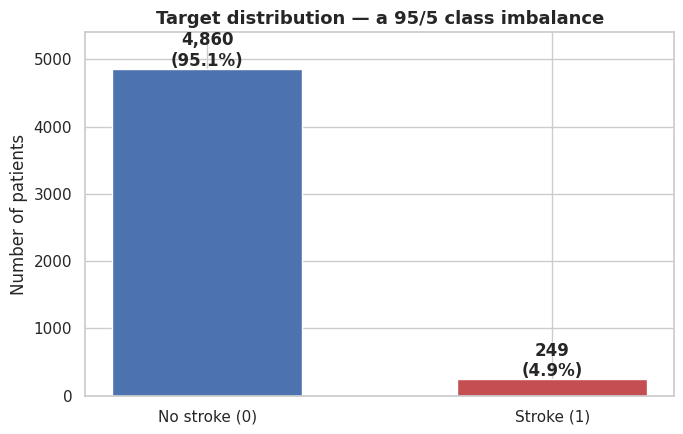

In [12]:
# 4.1 - The target: how imbalanced are we?
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = df['stroke'].value_counts()
bars = ax.bar(['No stroke (0)', 'Stroke (1)'], counts.values,
              color=[COLORS['no_stroke'], COLORS['stroke']], width=0.55)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontweight='bold')

ax.set_title('Target distribution — a 95/5 class imbalance', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of patients')
ax.set_ylim(0, 5400)
plt.tight_layout()
plt.show()

### 🚨 The central challenge of this project

Only **4.9% of patients (249 of 5,109)** had a stroke. Sit with what that means for a moment: a "model" that just prints *"no stroke"* for every single patient would score **~95% accuracy** while detecting **zero** stroke patients.

Two consequences I'm committing to now, *before* any modelling:

1. **Accuracy is banned as a headline metric.** I'll judge models on **recall** (what fraction of real strokes we catch — the metric that matters in medical screening, where a missed case is the expensive error) alongside **ROC-AUC** (how well the model ranks risk overall), with precision reported honestly.
2. **The imbalance must be handled explicitly** — I'll compare class weighting and SMOTE in Section 6.

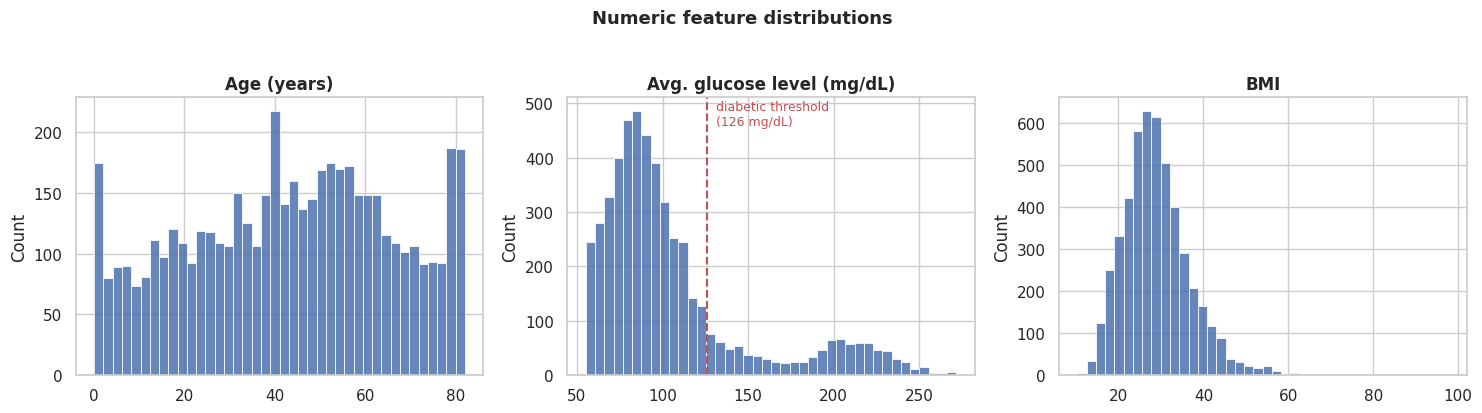

In [13]:
# 4.2 - Distributions of the numeric features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
                          ['age', 'avg_glucose_level', 'bmi'],
                          ['Age (years)', 'Avg. glucose level (mg/dL)', 'BMI']):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color=COLORS['no_stroke'], alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

axes[1].axvline(126, color=COLORS['stroke'], linestyle='--', linewidth=1.5)
axes[1].text(131, axes[1].get_ylim()[1]*0.9, 'diabetic threshold\n(126 mg/dL)',
             color=COLORS['stroke'], fontsize=9)

fig.suptitle('Numeric feature distributions', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### Reading the distributions

- **Age** is spread across the whole 0–82 range. This dataset really is "general population", not a cardiology clinic — which partly explains the low stroke rate.
- **Glucose is bimodal.** There's a main population centred around ~90 mg/dL and a clear second bump past the 126 mg/dL diabetic threshold (19.2% of patients). That second mode is essentially the diabetic subpopulation, and it's a candidate risk group.
- **BMI is right-skewed** with a long upper tail — this is exactly why I chose the **median** for imputation. The mean would be inflated by the tail.

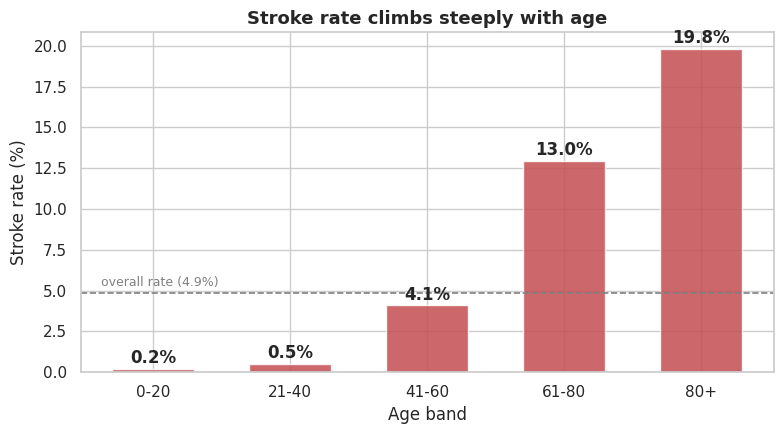

In [14]:
# 4.3 - Stroke rate by age band (the dominant pattern in this dataset)
age_bands = pd.cut(df['age'], bins=[0, 20, 40, 60, 80, 100],
                   labels=['0-20', '21-40', '41-60', '61-80', '80+'])
band_rate = df.groupby(age_bands, observed=True)['stroke'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(band_rate.index.astype(str), band_rate.values, color=COLORS['stroke'], alpha=0.85, width=0.6)
for bar, v in zip(bars, band_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.35, f'{v:.1f}%', ha='center', fontweight='bold')

ax.axhline(df['stroke'].mean()*100, color='gray', linestyle='--', linewidth=1.2)
ax.text(-0.38, df['stroke'].mean()*100 + 0.4, f"overall rate ({df['stroke'].mean()*100:.1f}%)", color='gray', fontsize=9)
ax.set_title('Stroke rate climbs steeply with age', fontsize=13, fontweight='bold')
ax.set_xlabel('Age band'); ax.set_ylabel('Stroke rate (%)')
plt.tight_layout()
plt.show()

**Age is, by a distance, the strongest single risk signal here.** The stroke rate climbs monotonically from **0.2%** in under-20s to **~20%** in the 80+ band — a 100× difference between the extremes. Any model that doesn't lean heavily on age is doing something wrong, and I'll verify later that mine does.

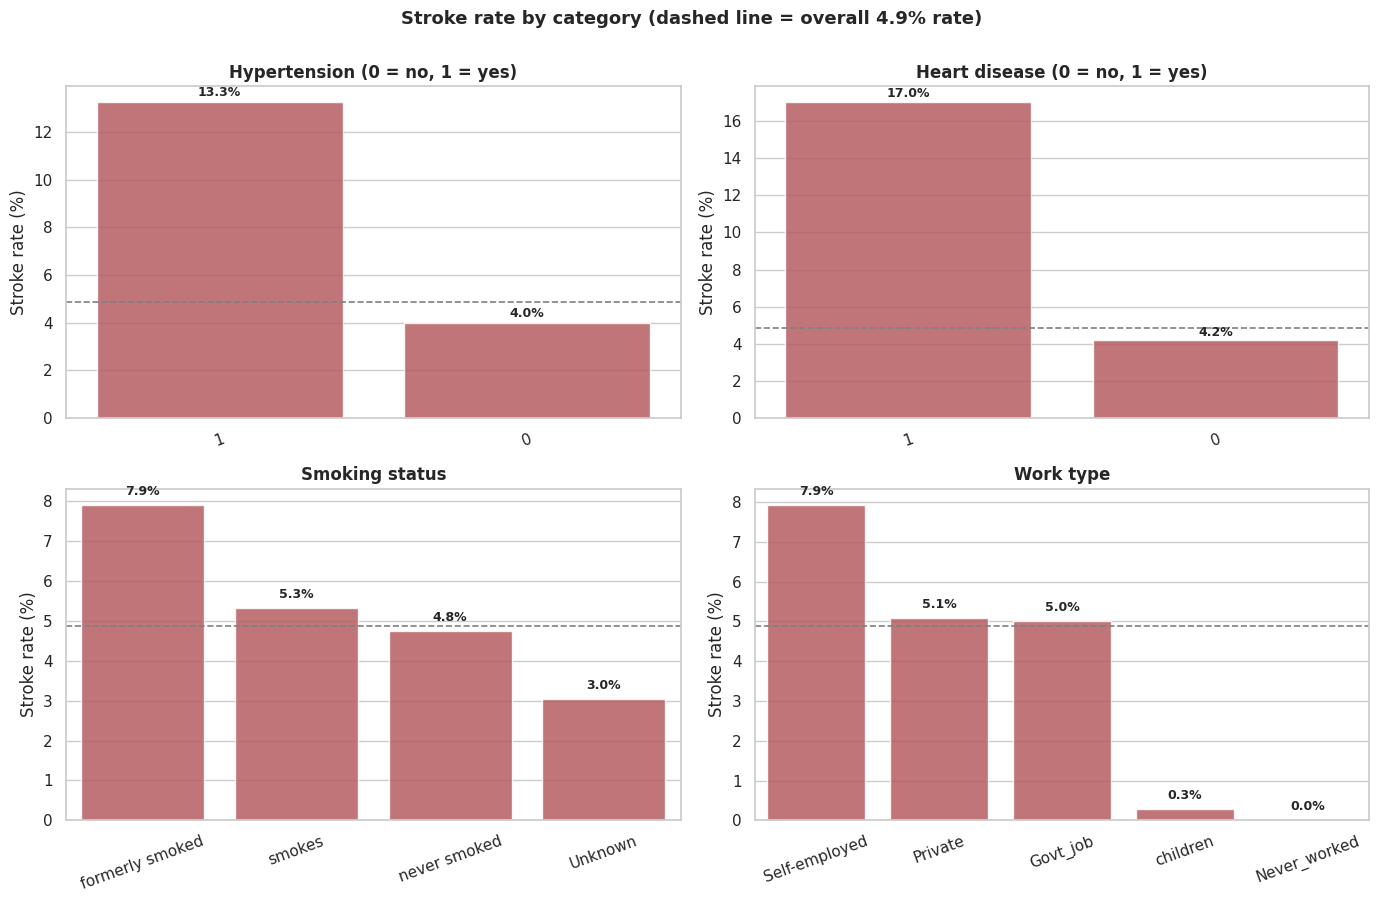

In [15]:
# 4.4 - Stroke rate across the key categorical / binary features
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
overall = df['stroke'].mean() * 100

plots = [
    ('hypertension',   'Hypertension (0 = no, 1 = yes)',  axes[0, 0]),
    ('heart_disease',  'Heart disease (0 = no, 1 = yes)', axes[0, 1]),
    ('smoking_status', 'Smoking status',                  axes[1, 0]),
    ('work_type',      'Work type',                       axes[1, 1]),
]

for col, title, ax in plots:
    rates = (df.groupby(col)['stroke'].mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, color=COLORS['stroke'], alpha=0.85)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.25, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
    ax.axhline(overall, color='gray', linestyle='--', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Stroke rate (%)')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Stroke rate by category (dashed line = overall 4.9% rate)', fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

### Reading the categorical patterns — carefully

- **Hypertension: 13.3% vs 4.0%.** Patients with hypertension have over 3× the stroke rate. Consistent with medical literature.
- **Heart disease: 17.0% vs 4.2%** — the single largest categorical gap, roughly 4× the baseline rate.
- **Smoking looks strange at first glance:** *former* smokers (7.9%) show a higher stroke rate than *current* smokers (5.3%). I don't believe quitting causes strokes — the far more likely explanation is **age confounding**: former smokers are, on average, older than current smokers, and age is the dominant risk factor. The "Unknown" group's low rate (3.0%) fits the same story — we saw it's mostly children.
- **Work type is mostly an age proxy too**: "children" (0.3%) and "Never_worked" (0%) have the lowest rates, self-employed the highest (7.9% — self-employed people skew older).

> ⚠️ **A note I want on the record:** these are raw associations in observational data, **not causal effects**. Several of them are tangled up with age. This is exactly why I'll prefer a model whose learned relationships I can inspect *after controlling for other features*, rather than reading too much into one-variable charts.

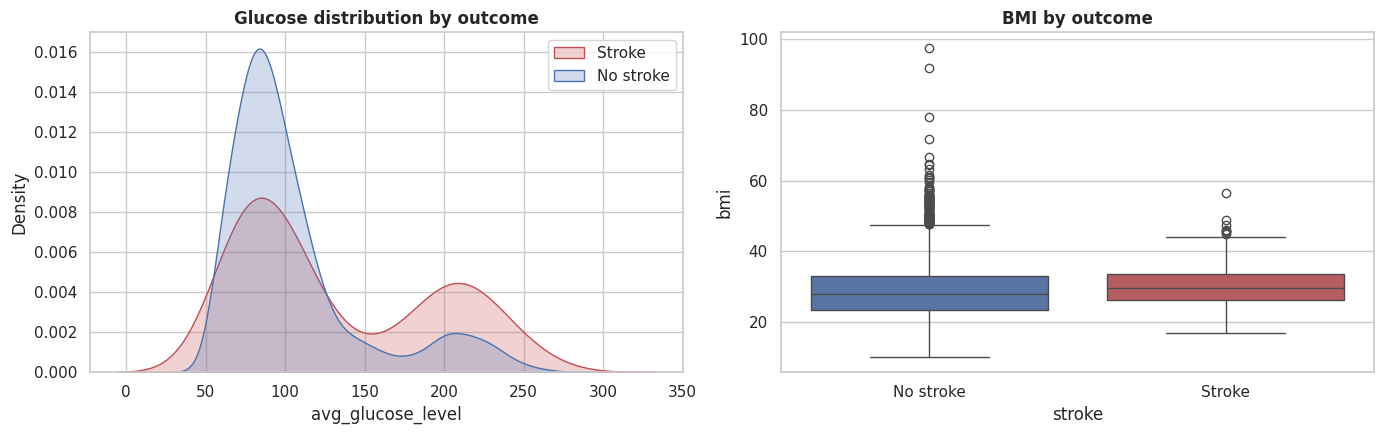

         age  avg_glucose_level   bmi
stroke                               
0       42.0              104.8  28.8
1       67.7              132.5  30.5


In [16]:
# 4.5 - Do glucose and BMI separate the classes?
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.kdeplot(data=df, x='avg_glucose_level', hue='stroke', common_norm=False, fill=True,
            palette=[COLORS['no_stroke'], COLORS['stroke']], ax=axes[0])
axes[0].set_title('Glucose distribution by outcome', fontweight='bold')
axes[0].legend(labels=['Stroke', 'No stroke'])

sns.boxplot(data=df, x='stroke', y='bmi', ax=axes[1],
            palette=[COLORS['no_stroke'], COLORS['stroke']])
axes[1].set_title('BMI by outcome', fontweight='bold')
axes[1].set_xticklabels(['No stroke', 'Stroke'])

plt.tight_layout()
plt.show()

print(df.groupby('stroke')[['age', 'avg_glucose_level', 'bmi']].mean().round(1))

- **Glucose:** stroke patients average **132.5 vs 104.8 mg/dL**, and the stroke curve has a visibly fatter right mode — the diabetic bump is over-represented among stroke patients. Real signal, but with heavy overlap between the classes.
- **BMI:** almost no separation (30.5 vs 28.8). I expected more here, honestly. BMI will likely be a weak feature, and I'll check whether the model agrees.
- **Age** (in the table) shows the starkest gap of all: stroke patients average **67.7 vs 42.0 years**.

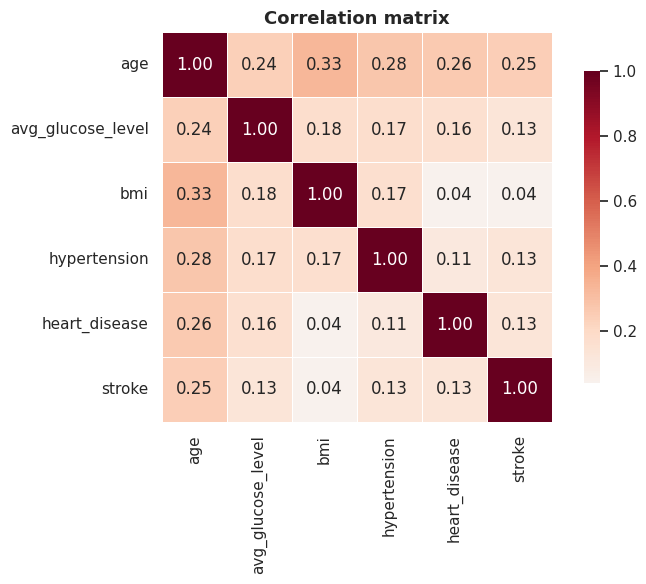

In [17]:
# 4.6 - Correlation heatmap (numeric + binary features + target)
corr_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA summary — what I'm taking into modelling

1. **Age dominates.** It has the strongest correlation with stroke of any numeric feature, and every age-related pattern in the categoricals points the same way.
2. **Hypertension, heart disease, and glucose** carry genuine additional signal.
3. **BMI and residence type look weak.**
4. **No worrying multicollinearity** between features — the strongest inter-feature correlation is age with the binary conditions, which is expected and mild. All correlations with stroke are individually modest, which tells me no single feature solves this; it's the combination that has to do the work.
5. **The 95/5 imbalance is the boss fight.** Metrics: recall + ROC-AUC. Strategy: class weights vs SMOTE, compared head-to-head.

## 5. Preprocessing — Building a Leakage-Free Pipeline

**The order of operations here matters more than people think.** I split the data **first**, and only then fit any preprocessing — imputation, scaling, encoding — on the *training* portion alone.

Why so strict? If I compute (say) the BMI median using **all** the data before splitting, then information about the test set has quietly contaminated training — the test set is supposed to simulate *patients the model has never seen*, and unseen patients don't get a vote in your imputation statistics. This is called **data leakage**, and it inflates your scores in ways that won't survive contact with real new data.

scikit-learn's `Pipeline` + `ColumnTransformer` make the correct behaviour automatic: every transform is fitted inside `.fit()` on training data only, and merely *applied* to the test data.

My preprocessing plan:

| Feature type | Columns | Transform |
|---|---|---|
| Numeric | `age`, `avg_glucose_level`, `bmi` | median imputation → standard scaling |
| Categorical | `gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status` | one-hot encoding (drop first level) |
| Binary | `hypertension`, `heart_disease` | pass through unchanged |

(Scaling doesn't affect the tree models but is important for Logistic Regression, whose optimizer and coefficients behave much better with standardized inputs.)

In [18]:
# 5.1 - Features/target and the stratified split
X = df.drop(columns='stroke')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]:,} rows  ({y_train.sum()} strokes, {y_train.mean()*100:.2f}%)')
print(f'Test : {X_test.shape[0]:,} rows  ({y_test.sum()} strokes, {y_test.mean()*100:.2f}%)')

Train: 4,087 rows  (199 strokes, 4.87%)
Test : 1,022 rows  (50 strokes, 4.89%)


`stratify=y` is non-negotiable with a 5% positive class — it forces both splits to preserve the stroke rate. A careless random split could easily land too few stroke cases in the test set to evaluate on. As it stands, my entire evaluation of "can this model catch strokes" rests on **just 50 positive cases** in the test set — one more reason to confirm results with cross-validation later.

In [19]:
# 5.2 - The preprocessing pipeline
numeric_features = ['age', 'avg_glucose_level', 'bmi']
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
binary_features = ['hypertension', 'heart_disease']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),   # fitted on TRAIN only
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('bin', 'passthrough', binary_features),
])

# Quick check of what comes out the other end
_check = preprocessor.fit_transform(X_train)
print(f'{X_train.shape[1]} raw features -> {_check.shape[1]} model-ready features:')
print(list(preprocessor.get_feature_names_out()))

10 raw features -> 15 model-ready features:
['num__age', 'num__avg_glucose_level', 'num__bmi', 'cat__gender_Male', 'cat__ever_married_Yes', 'cat__work_type_Never_worked', 'cat__work_type_Private', 'cat__work_type_Self-employed', 'cat__work_type_children', 'cat__Residence_type_Urban', 'cat__smoking_status_formerly smoked', 'cat__smoking_status_never smoked', 'cat__smoking_status_smokes', 'bin__hypertension', 'bin__heart_disease']


## 6. Modelling

### The plan

1. **Naive baseline first** — plain Logistic Regression, no imbalance handling. I fully expect it to fail in an instructive way, and I want that failure documented.
2. **Two imbalance strategies, two algorithms:**
   - **Class weighting** (`class_weight='balanced'`): reweights the loss so minority errors cost more. With our training balance, each stroke patient counts roughly **20×** as much as a non-stroke patient (the weight for class $c$ is $\frac{n}{k \cdot n_c}$ — I like that this is a pure loss-function fix: no fake data, just changed penalties).
   - **SMOTE**: generates synthetic minority samples by interpolating between real stroke cases and their nearest neighbours. Crucially, it's applied **only to training folds** inside an `imblearn` pipeline — oversampling before the split would leak synthetic copies of test-adjacent points into training.
3. **One comparison table + cross-validation** to pick a winner on the metrics that matter: **recall** and **ROC-AUC**.

In [20]:
# 6.1 - A single evaluation helper so every model is judged identically
results = []

def evaluate_model(name, model, note=''):
    """Fit on train, evaluate on test, store metrics, return fitted model."""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
    })

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print(f'{name:<38} | strokes caught: {tp}/{tp+fn}  | false alarms: {fp}  {note}')
    return model

In [21]:
# 6.2 - The naive baseline
baseline = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
baseline = evaluate_model('Logistic Regression (no balancing)', baseline)

pd.DataFrame(results).round(3)

Logistic Regression (no balancing)     | strokes caught: 1/50  | false alarms: 0  


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression (no balancing),0.952,1.0,0.02,0.039,0.839


### 📉 The accuracy trap, live

**95.2% accuracy. 1 stroke caught out of 50.**

If I had reported this project with accuracy as the headline, it would look excellent — and it would be worthless as a screening tool: it misses **98% of the patients it exists to find**. The model discovered that predicting "no stroke" is almost always safe under an unweighted loss, and settled there. Note its ROC-AUC is actually decent (0.839) — it *ranks* risk fine; its default 0.5 decision threshold is just useless under this imbalance.

This is the clearest demonstration I know of why **metric choice comes before model choice**. Now let's fix it.

In [22]:
# 6.3 - Class weighting and SMOTE, across Logistic Regression and Random Forest
models = {
    'Logistic Regression + class weights': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest (no balancing)': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
    ]),
    'Random Forest + class weights': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Logistic Regression + SMOTE': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Random Forest + SMOTE': ImbPipeline([
        ('pre', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
    ]),
}

fitted = {'Logistic Regression (no balancing)': baseline}
for name, model in models.items():
    fitted[name] = evaluate_model(name, model)

Logistic Regression + class weights    | strokes caught: 40/50  | false alarms: 257  


Random Forest (no balancing)           | strokes caught: 0/50  | false alarms: 1  


Random Forest + class weights          | strokes caught: 0/50  | false alarms: 1  
Logistic Regression + SMOTE            | strokes caught: 40/50  | false alarms: 264  


Random Forest + SMOTE                  | strokes caught: 7/50  | false alarms: 21  


In [23]:
# 6.4 - Head-to-head comparison
results_df = (pd.DataFrame(results)
                .set_index('Model')
                .sort_values('ROC-AUC', ascending=False)
                .round(3))
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression + class weights,0.739,0.135,0.80,0.231,0.839
Logistic Regression + SMOTE,0.732,0.132,0.80,0.226,0.839
Logistic Regression (no balancing),0.952,1.000,0.02,0.039,0.839
Random Forest (no balancing),0.950,0.000,0.00,0.000,0.803
Random Forest + class weights,0.950,0.000,0.00,0.000,0.794
Random Forest + SMOTE,0.937,0.250,0.14,0.179,0.778


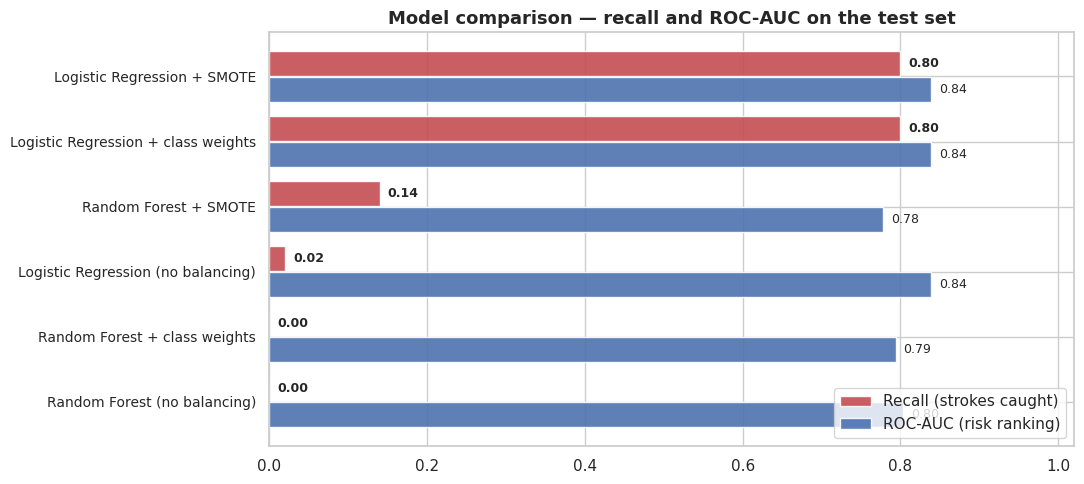

In [24]:
# 6.5 - Visual comparison on the two metrics I care about
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = results_df[['Recall', 'ROC-AUC']].sort_values('Recall')

x = np.arange(len(plot_df))
ax.barh(x + 0.2, plot_df['Recall'], height=0.38, label='Recall (strokes caught)', color=COLORS['stroke'], alpha=0.9)
ax.barh(x - 0.2, plot_df['ROC-AUC'], height=0.38, label='ROC-AUC (risk ranking)', color=COLORS['no_stroke'], alpha=0.9)

ax.set_yticks(x)
ax.set_yticklabels(plot_df.index, fontsize=10)
for i, (rec, auc) in enumerate(zip(plot_df['Recall'], plot_df['ROC-AUC'])):
    ax.text(rec + 0.01, i + 0.2, f'{rec:.2f}', va='center', fontsize=9, fontweight='bold')
    ax.text(auc + 0.01, i - 0.2, f'{auc:.2f}', va='center', fontsize=9)

ax.set_xlim(0, 1.02)
ax.set_title('Model comparison — recall and ROC-AUC on the test set', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Reading the comparison — three honest takeaways

1. **Weighted Logistic Regression wins.** Best ROC-AUC (0.839, tied with its SMOTE variant), 80% recall — it catches **40 of 50** strokes. The cost is precision (0.135): roughly 7 false alarms per true catch. In a *screening* context — where a flag means "order follow-up tests", not "administer treatment" — that trade is often acceptable, and I examine it properly in the threshold analysis below.

2. **Random Forest flat-out failed at recall — even with class weights (0 of 50 caught).** This genuinely surprised me, and it's worth understanding rather than hiding: fully-grown trees can isolate the few minority samples into tiny pure leaves, so the forest's *probability estimates* for unseen minority-like points stay low and almost nothing crosses the 0.5 threshold; sample weighting doesn't change that geometry much. Its high accuracy (0.950) is the accuracy trap all over again — **the model with the best accuracy in this table is the single worst screening tool in it.**

3. **SMOTE ≈ class weights for Logistic Regression, and SMOTE didn't rescue the forest either** (it helped recall slightly — 7/50 — at the cost of ranking quality, likely from overfitting to interpolated synthetic points). Given equal performance, I prefer class weights: simpler, no synthetic data to explain, one fewer moving part.

> The broader lesson I'm taking from this table: **"more complex" is not "better."** A weighted linear model beat a 300-tree ensemble on every metric that matters for this problem.

In [25]:
# 6.6 - Cross-validation: is this ranking real, or a lucky split?
# (50 test strokes is a small sample - I don't fully trust a single split)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_candidates = ['Logistic Regression + class weights', 'Logistic Regression + SMOTE',
                 'Random Forest + class weights', 'Random Forest + SMOTE']

print('5-fold cross-validated ROC-AUC (training data):\n')
for name in cv_candidates:
    scores = cross_val_score(models[name], X_train, y_train, cv=cv, scoring='roc_auc')
    print(f'  {name:<38} {scores.mean():.3f} ± {scores.std():.3f}')

5-fold cross-validated ROC-AUC (training data):

  Logistic Regression + class weights    0.839 ± 0.019


  Logistic Regression + SMOTE            0.834 ± 0.025


  Random Forest + class weights          0.815 ± 0.025


  Random Forest + SMOTE                  0.805 ± 0.023


Cross-validation confirms the single-split ranking: **weighted Logistic Regression leads (0.839 ± 0.019)**, with tight variance across folds — this isn't a lucky split. **Final model selected: Logistic Regression with `class_weight='balanced'`.**

## 7. Final Model — A Closer Look

Model selection is done; now I want to understand the chosen model properly: exactly where its errors fall, how its threshold trades precision against recall, and *what it actually learned* — do its internals agree with the EDA?

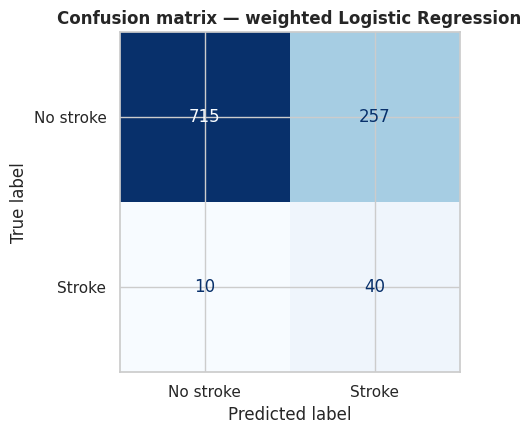

In [26]:
final_model = fitted['Logistic Regression + class weights']
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No stroke', 'Stroke'],
    cmap='Blues', values_format='d', colorbar=False, ax=ax
)
ax.set_title('Confusion matrix — weighted Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

Reading the four quadrants at the default 0.5 threshold:

- ✅ **40 true positives** — 80% of actual strokes flagged
- ❌ **10 false negatives** — real strokes missed. In screening, these are the errors that matter most.
- ⚠️ **257 false positives** — patients flagged who didn't have a stroke. This is the price of high recall on a 5%-prevalence problem, and whether it's acceptable depends entirely on what a flag *triggers* (a cheap follow-up test vs. an expensive intervention).
- ✅ **715 true negatives**

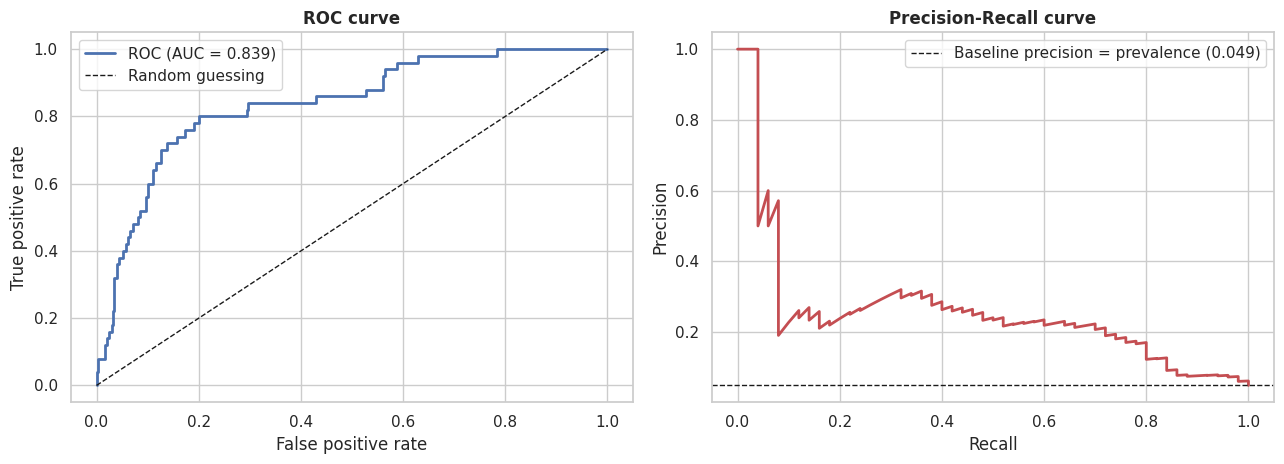

In [27]:
# 7.1 - ROC and Precision-Recall curves
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(fpr, tpr, color=COLORS['no_stroke'], lw=2,
             label=f'ROC (AUC = {roc_auc_score(y_test, y_prob):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random guessing')
axes[0].set_xlabel('False positive rate'); axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curve', fontweight='bold'); axes[0].legend()

axes[1].plot(rec, prec, color=COLORS['stroke'], lw=2)
axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=1,
                label=f'Baseline precision = prevalence ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall curve', fontweight='bold'); axes[1].legend()

plt.tight_layout()
plt.show()

Two views, two different stories — both true:

- **ROC (AUC = 0.839):** given a random stroke patient and a random non-stroke patient, the model ranks the stroke patient as higher-risk **~84% of the time**. Solid risk *ranking* for a linear model on 10 routine features.
- **Precision–Recall:** the honest view under imbalance. Precision stays low across most recall levels — but note the dashed line: a random model would sit at **precision ≈ 0.05** (the prevalence). At 80% recall the model's precision of ~0.14 is roughly **3× better than chance**. Low in absolute terms, meaningfully better than the base rate.

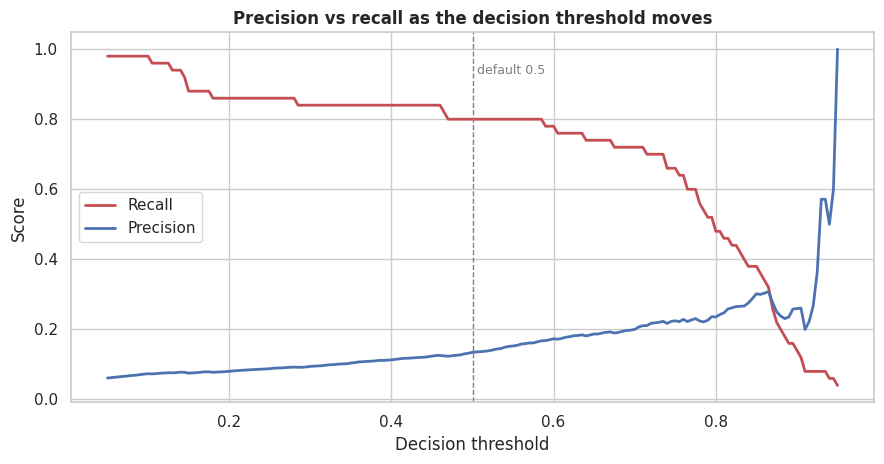

Threshold |  Precision |  Recall  | Strokes caught (of 50)
   0.3    |    0.094   |  0.840   |   42
   0.5    |    0.135   |  0.800   |   40
   0.7    |    0.200   |  0.720   |   36


In [28]:
# 7.2 - The threshold is a decision, not a default
thresholds = np.linspace(0.05, 0.95, 181)
prec_t = [precision_score(y_test, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
rec_t  = [recall_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(thresholds, rec_t, color=COLORS['stroke'], lw=2, label='Recall')
ax.plot(thresholds, prec_t, color=COLORS['no_stroke'], lw=2, label='Precision')
ax.axvline(0.5, color='gray', linestyle='--', lw=1)
ax.text(0.505, 0.93, 'default 0.5', color='gray', fontsize=9)
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
ax.set_title('Precision vs recall as the decision threshold moves', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Threshold |  Precision |  Recall  | Strokes caught (of 50)')
for t in [0.3, 0.5, 0.7]:
    p = (y_prob >= t).astype(int)
    print(f'   {t:.1f}    |    {precision_score(y_test, p, zero_division=0):.3f}   |  {recall_score(y_test, p):.3f}   |   {int(((p==1)&(y_test==1)).sum())}')

The 0.5 threshold is just a default — **in a deployed system, this choice belongs to the use case**, not to scikit-learn:

| If the cost of… | …then choose | Example |
|---|---|---|
| a **missed stroke** dominates (screening, cheap follow-up test) | lower threshold, e.g. **0.3** → 84% recall | population screening programme |
| a **false alarm** is expensive (invasive follow-up, limited capacity) | higher threshold, e.g. **0.7** → precision rises to 0.20, recall falls to 72% | prioritising scarce specialist slots |

For a screening framing, I'd argue for **0.5 or lower** and accept the false-alarm load. But the real answer requires cost numbers I don't have — which I'm flagging as a limitation rather than pretending the default is principled.

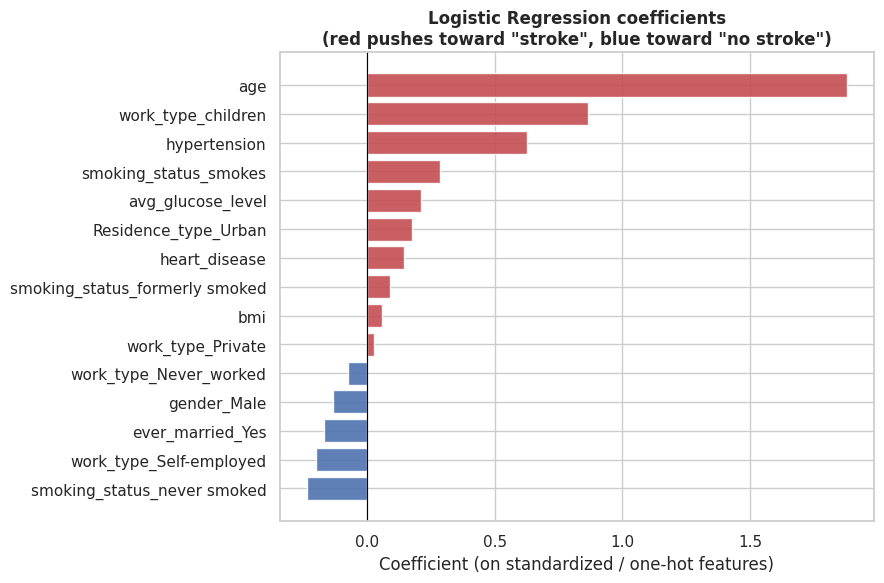

In [29]:
# 7.3 - What did the model actually learn? (coefficient inspection)
feature_names = final_model.named_steps['pre'].get_feature_names_out()
clean_names = [n.split('__')[1] for n in feature_names]
coefs = pd.Series(final_model.named_steps['clf'].coef_[0], index=clean_names).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = [COLORS['stroke'] if c > 0 else COLORS['no_stroke'] for c in coefs.values]
ax.barh(coefs.index, coefs.values, color=colors, alpha=0.9)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression coefficients\n(red pushes toward "stroke", blue toward "no stroke")',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient (on standardized / one-hot features)')
plt.tight_layout()
plt.show()

### Does the model agree with the EDA? Mostly, yes — and where it doesn't, there's a lesson

- **`age` towers over everything (+1.88).** Because numeric features are standardized, coefficients are roughly comparable: one standard deviation of age moves the log-odds of stroke about 9× more than a standard deviation of glucose. This matches the EDA exactly.
- **`hypertension` (+0.63), `avg_glucose_level` (+0.21), and `smokes` (+0.28)** all push risk upward, with `never smoked` protective (−0.24) — all medically sensible directions.
- **One artifact worth being honest about:** `work_type_children` gets a *positive* coefficient (+0.87), which looks absurd — children have the lowest raw stroke rate in the data. What's happening: that category overlaps almost perfectly with low `age`, so *after* age is controlled for, the coefficient is left fitting noise in a tiny subgroup rather than a real effect. It's a textbook reminder that **coefficients are conditional effects ("holding everything else fixed"), not standalone facts** — and that near-redundant features make individual coefficients unstable even when predictions stay fine.

## 8. Conclusions

### What I found

| Question | Answer |
|---|---|
| Can routine health records predict stroke risk? | **Partially.** ROC-AUC of **0.839** — good risk *ranking*, far from deterministic prediction. |
| Best model? | **Logistic Regression with class weights** — it beat Random Forest (with and without weights/SMOTE) on every metric that matters here. |
| Best screening performance? | **80% recall** (40/50 strokes caught) at 0.5 threshold, at a precision of 0.135 — ~3× the base rate. |
| Biggest risk factors the model learned? | **Age** (dominant), then hypertension, glucose, smoking — consistent with both the EDA and medical literature. |

### What I learned building this

1. **Investigate missingness before deleting.** The rows with missing BMI had a **4× stroke rate**; `dropna()` would have deleted 16% of the positive class and I'd never have known.
2. **Accuracy is a trap under class imbalance** — my most "accurate" model (95%) caught zero strokes. Pick the metric before you pick the model.
3. **Complexity must earn its place.** A weighted linear model beat a 300-tree forest. I'd rather ship the simple model I can explain.
4. **Leakage discipline** (split → then fit preprocessing, SMOTE inside the pipeline) costs one extra line of code and is the difference between real scores and self-deception.
5. **The decision threshold is a product/clinical decision**, not a modelling default.

### Limitations — where this analysis is weakest

- **Only 249 positive cases** (50 in the test set). All test-set metrics carry real sampling noise; CV mitigates but doesn't eliminate this.
- **Dataset provenance is opaque** (Kaggle states the source is confidential; collection methodology, population, and time period are unknown), so nothing here should be assumed to transfer to any specific real population — for me, that especially includes the Nigerian context I care about.
- **Median imputation of BMI is a simplification.** The missingness looked informative (MNAR-ish); a missingness-indicator feature or model-based imputation would respect that structure better.
- **Cross-sectional snapshot** — `stroke` records whether a stroke *has occurred*, with no timing. This model associates profiles with outcomes; it does not forecast *future* risk the way a proper longitudinal/survival analysis could.
- No hyperparameter tuning beyond sensible defaults, and no probability calibration check — deliberate scope choices to keep the focus on process, but they belong in the next iteration.

### Next steps

- [ ] Gradient boosting (XGBoost / LightGBM) with tuned depth + `scale_pos_weight`, evaluated on PR-AUC
- [ ] Probability **calibration curves** — a risk score you can't trust as a probability is only half useful
- [ ] Missingness-indicator feature for BMI + comparison against model-based imputation
- [ ] SHAP values for patient-level explanations
- [ ] Wrap the final pipeline in a small **Streamlit app** for interactive risk scoring

---

### References

- Dataset: [Stroke Prediction Dataset — fedesoriano, Kaggle](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)
- WHO — [The top 10 causes of death](https://www.who.int/news-room/fact-sheets/detail/the-top-10-causes-of-death)
- scikit-learn documentation — [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- imbalanced-learn documentation — [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)

*Thanks for reading. Feedback and pull requests are welcome — I'm always trying to improve how I work.* 🚀